# LABOR-9: Aufbau einer Funkstrecke mit 433MHz ISM-Band Sender und einem RF-Empfänger Front-End

### Ziel

Ein 433MHz Sendemodul soll einen unmodulierten Träger aussenden. Ziel der Übung ist der Aufbau eines RF-Frontends mit 2 Verstärker, einem Kanalbandfilter und einer Mischstufe, um das mit der Antenne empfangene Signal auf 300MHz Zwischenfrequenz zu verschieben. 

Dafür sollen die unten angeführten Komponenten verwendet werden.

### Wichtig: Messreihenfolge

**Es sind sieben Messungen in unmittelbarer Abfolge auszuführen** .
Zwischen den Messungen wird die **Messkonfiguration am Aufbau** geändert (Kabel/Führung zum Spektrumanalysator,
ggf. Span/Referenzpegel am Gerät). Das Notebook speichert nach jeder Live-Messung die Daten in eine gemeinsame Replay-Datei.


### Darstellung (Plots)

Die sechs Spektren nutzen **eigene Figure-IDs** (`spectrum_ant` / `spectrum_amp1` / `spectrum_amp2`), damit sie sich nicht mit anderen matplotlib-Figuren überschneiden. Beim Speichern erscheint eine **Verifikationszeile** mit allen sechs Spektren in der JSON-Datei. Marker-Steuerung: **`ipywidgets.IntSlider`** (Trace-Bin) unterhalb des Plots, plus **`-1`/`+1` Buttons** für Schrittbewegungen um genau einen Bin (nützlich zur exakten Peaksuche). Nicht `matplotlib.widgets.Slider`, der mit **ipympl** in Jupyter/VS Code oft zu eingefrorenen Controls führt. Voraussetzungen: **`pip install ipympl`** (`%matplotlib widget`) und **`pip install ipywidgets`**. **`plt.ioff()`** vor dem Erzeugen der Figure verhindert die automatische ipympl-Zweitausgabe; zusammen mit **`display(VBox([fig.canvas, slider, buttons]))`** sonst **doppelter Plot**. Für nur statische Bilder testweise **`%matplotlib inline`**.


## Gerät: Spektrum-Analyzer (Kurzinfo)

- **Mode:** *Spectrum Analyzer* am FPC1500 wählen.
- **Freq / Span:** Span so setzen, dass der erwartete Peak (LO, IF bzw. RF/Mischprodukte) gut sichtbar ist.
- **BW:** RBW/VBW nach Bedarf (feinere RBW → langsamer, schärfere Peaks).
- **Ampt:** Reference Level so wählen, dass der Trace nicht clippt.

Netzwerk: IP **`192.168.1.10`**, SCPI-Port **`5555`** (wie in den anderen Labor-Notebooks).


## ISM-Band Sender

Das Sendemodul wird mit einem Netzteil mit +3.3V betrieben, es wird keine Sendeantenne angeschlossen, weil die Sendeleistung ohnehin ausreichend ist und zu keiner Übersteuerung der Empfängerschaltung führen soll.

![ISM-band 433MHz Transmitter](media\433mhz-tx.png)

## Frequency-Mixer ZX05-1-S+ 

[Link to Minicircuits Product Page](https://www.minicircuits.com/WebStore/dashboard.html?model=ZX05-1-S%2B)



![Mixer](media\mixer.png)



## RF-Amplifier:

- nooelec Breitband LNA
- RF-Amplifier Modul

[Amazon Produktseite](https://www.amazon.de/dp/B0DZCP56KJ?ref=ppx_yo2ov_dt_b_fed_asin_title)

![](media/amplifiers.png)

## SAW-Filter für 433MHz ISM Band

![SAW Filter](media\SAW-filter.png)

## LO-Signal Generator:  10K-220MHz VFO/RF Generator (SDR QRP HAM Transmitter)

![](media/IF-generator.png)

## Diverse SMA-Kupplungen und RG-174 SMA Koaxialkabel

![SMA Kabel und Kupplungen](media\SMA-Kabel.png)

## HIER einfügen: Foto vom Messaufbau 
Bild zeigt Messaufbau von der letzten Messung 

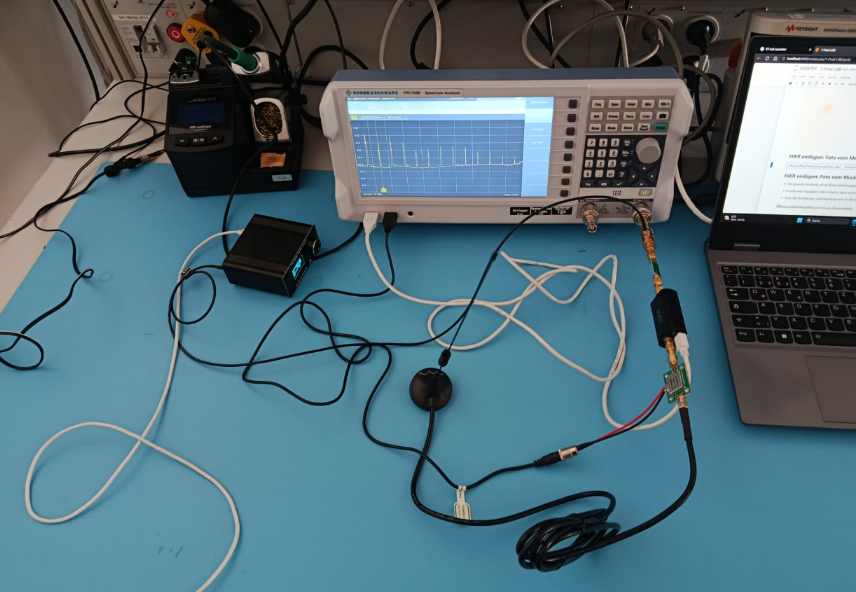


## HIER einfügen: Foto vom Blockschaltbild (z.B. Handzeichnung)

- Die gesamte Schaltung soll als Blockschaltbild abgebildet werden.

- Erstelle einen Signalplan, indem Pegel (in dBm) und Frequenz des Nutzsignals an allen Knoten im Blockschaltbild eingezeichnet werden.

- Trage alle Verstärkungs- und Dämpfungswerte (in dB) für die verwendeten Komponenten ein (für Mischer gilt: Conversion Gain, für Filter gilt: Insertion Loss).

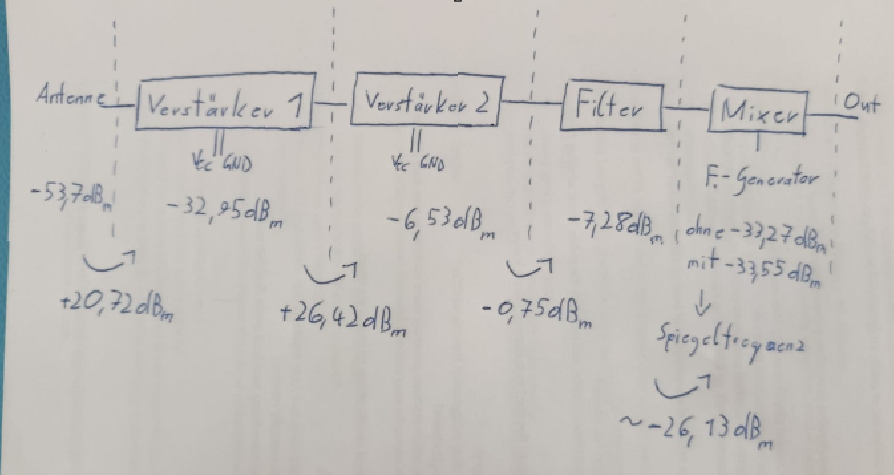

## Globale Parameter und Imports

In [1]:

import json
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().resolve()))

from lib.plot_style import apply_lab_matplotlib_style

apply_lab_matplotlib_style()

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 10.0
TRACE_READ_MAX_BYTES = 256 * 1024

REPLAY = True
REPLAY_FILE = Path("recordings") / "1-final-lab_replay.json"
SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

## SCPI und Plot Hilfsfunktionen, File Save /Replay Funktionen

In [2]:
from lib.replay_json import load_replay_json, save_replay_json
from lib.scpi_tcp import get_trace_data, scpi_query, screenshot_read, screenshot_save
from lib.mixer_plots import mixer_merge_save, plot_mixer_spectrum

print("Konfiguration:", FPC_IP, "Port", FPC_PORT)
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")


Konfiguration: 192.168.1.10 Port 5555
REPLAY=True, Datei=recordings\1-final-lab_replay.json


### Verbindung testen (`*IDN?`)

Prüfen, ob der FPC1500 per SCPI erreichbar ist.


In [3]:
if REPLAY:
    try:
        replay = load_replay_json(REPLAY_FILE)
        idn_reply = replay.get("idn", "REPLAY")
        print("Gerät (Replay):", idn_reply)
    except FileNotFoundError:
        idn_reply = "REPLAY (keine Datei)"
        print("Replay-Datei noch nicht vorhanden — bitte später Live-Messungen ausführen.")
else:
    idn_reply = scpi_query(FPC_IP, FPC_PORT, "*IDN?", socket_timeout=SOCKET_TIMEOUT)
    print("Gerät:", idn_reply if idn_reply else "Keine Antwort (IP/Port prüfen?)")


Gerät (Replay): Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90


### Messung 1 — Spektrum am Antennen-Eingang

**Messablauf**

1. Antenne direkt an den Spektrum-Analyzer anschließen.
2. Am FPC1500 **Spectrum Analyzer** wählen; **Span / Center** so setzen, dass das empfangene Signal bei Center Frequency sichtbar ist.
3. Wähle verschiedene Kombinationen von Span und BW (Resolution Bandwidth), um eine möglichst exakte Messung der Signalleistung zu erreichen. (Anmerkung: bei ungündtiger Koombination wird die Leistungsmessung fehlerhaft).
4. Mit "Mkr>"  "Set To Peak" Setze den Marker auf die Spektrallinie des Signals, und bestimme die exakte Frequenz und Leistung des Signals. 
5. Warten bis der Trace stabil ist, dann **diese Code-Zelle** ausführen.

Die Daten werden unter dem Schlüssel `spectrum_ant` in der Replay-Datei abgelegt.


In [4]:
key = "spectrum_ant"
title = "Messung 1: Antenna-Spektrum"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError("Replay ohne spectrum_ant — Messung 1 fehlt oder alte Datei.")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten — Mode SA? Span? Trigger?")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_dbm = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_dbm,
    rbw_hz,
    title,
    fig_id="ant",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)


Replay: spectrum_ant — 1183 Samples


Punkte: 1183, f = 430.0000 … 438.0000 MHz


### Messung 2 — Spektrum nach erster Verstärkerstufe

**Messablauf**

1. Messpunkt/Messkoppler auf das **IF-Signal** umlegen (gleicher Messmodus am FPC: Spektrum).
2. Span/Center an die **IF-Frequenz** anpassen; Trace stabil.
3. **Diese Zelle ausführen** (speichert `spectrum_if`).

> Die drei Messungen bauen aufeinander auf — bitte **ohne lange Pause** nacheinander durchführen,
> damit Geräteeinstellungen und Beschriftung zusammenpassen.


In [5]:
key = "spectrum_amp1"
title = "Messung 2: RF-AMP1-Spektrum"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError("Replay ohne spectrum_amp1.")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten.")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_dbm = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_dbm,
    rbw_hz,
    title,
    fig_id="rf-amp1",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)


Replay: spectrum_amp1 — 1183 Samples


Punkte: 1183, f = 430.0000 … 438.0000 MHz


### Messung 3 — Spektrum nach zweiter Verstärkerstufe

**Messablauf**

1. Messpunkt/Messkoppler auf das **IF-Signal** umlegen (gleicher Messmodus am FPC: Spektrum).
2. Span/Center an die **IF-Frequenz** anpassen; Trace stabil.
3. **Diese Zelle ausführen** (speichert `spectrum_if`).

> Die drei Messungen bauen aufeinander auf — bitte **ohne lange Pause** nacheinander durchführen,
> damit Geräteeinstellungen und Beschriftung zusammenpassen.


In [6]:
key = "spectrum_amp2"
title = "Messung 3: RF-AMP2-Spektrum"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError("Replay ohne spectrum_amp1.")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten.")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_dbm = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_dbm,
    rbw_hz,
    title,
    fig_id="rf-amp2",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)


Replay: spectrum_amp2 — 1183 Samples


Punkte: 1183, f = 430.0000 … 438.0000 MHz


### Messung 4 — Spektrum nach **Filter**, am **RF-Eingang** des Mischers

**Messablauf**

1. Messung am **RF-Ausgang** (bzw. nach dem Mischer in der RF-Kette) — Span so wählen, dass **LO-Leck**, **IF-Mischprodukt**
   und ggf. **RF-Träger** im Spektrum beobachtet werden können (exakte Lage hängt vom Aufbau ab).
2. Trace stabil, dann **diese Zelle ausführen** (speichert `spectrum_rf`).

Damit liegen alle drei Spektren in einer gemeinsamen Replay-Datei für die Auswertung.


In [7]:
key = "spectrum_mixer_rf"
title = "Messung 4: RF-Mixer-In Spektrum"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError("Replay ohne spectrum_mixer_rf.")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten.")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_dbm = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_dbm,
    rbw_hz,
    title,
    fig_id="mixer_rf",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)


Replay: spectrum_mixer_rf — 1183 Samples


Punkte: 1183, f = 430.0000 … 438.0000 MHz


### Messung 5 — Spektrum am **IF-Ausgang** des Mischers

**Messablauf**

1. Messung am **RF-Ausgang** (bzw. nach dem Mischer in der RF-Kette) — Span so wählen, dass **LO-Leck**, **IF-Mischprodukt**
   und ggf. **RF-Träger** im Spektrum beobachtet werden können (exakte Lage hängt vom Aufbau ab).
2. Trace stabil, dann **diese Zelle ausführen** (speichert `spectrum_rf`).

Damit liegen alle drei Spektren in einer gemeinsamen Replay-Datei für die Auswertung.


In [8]:
key = "spectrum_mixer_if"
title = "Messung 5: IF-Mixer-Out Spektrum"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError("Replay ohne spectrum_mixer_if.")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten.")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_dbm = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_dbm,
    rbw_hz,
    title,
    fig_id="mixer_if",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)


Replay: spectrum_mixer_if — 1183 Samples


Punkte: 1183, f = 430.0000 … 438.0000 MHz


### Messung 6 — Spektrum am **IF-Ausgang** des Mischers - Spiegelfrequenz

**Messablauf**

1. Messung am **RF-Ausgang** (bzw. nach dem Mischer in der RF-Kette) — Span so wählen, dass **LO-Leck**, **IF-Mischprodukt**
   und ggf. **RF-Träger** im Spektrum beobachtet werden können (exakte Lage hängt vom Aufbau ab).
2. Trace stabil, dann **diese Zelle ausführen** (speichert `spectrum_rf`).

Damit liegen alle drei Spektren in einer gemeinsamen Replay-Datei für die Auswertung.


In [9]:
key = "spectrum_mixer_if-image"
title = "Messung 6: IF-Mixer-Out Image Spektrum"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError("Replay ohne spectrum_mixer_if-image.")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten.")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_dbm = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_dbm,
    rbw_hz,
    title,
    fig_id="mixer_if_image",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)


Replay: spectrum_mixer_if-image — 1183 Samples


Punkte: 1183, f = 430.0000 … 438.0000 MHz


### Messung 7 — Spektrum am **IF-Ausgang** des Mischers - Full Span

**Messablauf**

1. Messung am **RF-Ausgang** (bzw. nach dem Mischer in der RF-Kette) — Full Span wählen.
   
2. Trace stabil, dann **diese Zelle ausführen** .

Damit liegen alle drei Spektren in einer gemeinsamen Replay-Datei für die Auswertung.


In [10]:
key = "spectrum_mixer_if-fullspan"
title = "Messung 7: IF-Mixer-Out Full Span Spectrum"

if REPLAY:
    data = load_replay_json(REPLAY_FILE)
    blk = data.get(key)
    if not blk:
        raise RuntimeError("Replay ohne spectrum_mixer_if-fullspan.")
    freqs = blk["freqs_hz"]
    amps = blk["amps"]
    rbw_hz = blk.get("rbw_hz")
    print("Replay:", key, "—", len(amps), "Samples")
else:
    result = get_trace_data(
        FPC_IP,
        FPC_PORT,
        trace_read_max_bytes=TRACE_READ_MAX_BYTES,
        socket_timeout=SOCKET_TIMEOUT,
    )
    if result is None:
        raise RuntimeError("Keine Trace-Daten.")
    freqs, amps, rbw_hz = result
    mixer_merge_save(
        key,
        freqs,
        amps,
        rbw_hz,
        idn_reply,
        replay_file=REPLAY_FILE,
    )

freq_hz = np.asarray(freqs, dtype=float)
p_dbm = np.asarray(amps, dtype=float)
plot_mixer_spectrum(
    freq_hz,
    p_dbm,
    rbw_hz,
    title,
    fig_id="mixer_if_fullscan",
    replay=REPLAY,
    widgets_module=widgets,
    display_fn=display,
)


Replay: spectrum_mixer_if-fullspan — 1183 Samples


Punkte: 1183, f = 0.0000 … 3000.0000 MHz


## Aufgaben zur Auswertung (nach allen sieben Messungen)

Nutze die gespeicherten Spektren bzw. die Plots oben.

1. **Pegel des empfangenen Signals auf der Antenne**  
   Bestimme den **Pegel in dBm** für das RF-Signal (z. B. mit Marker/Peak in den gespeicherten Traces oder über den Maximalwert im relevanten Frequenzbereich).

2. **Verstärkungsfaktor der ersten Verstärkerstufe**  
3. **Verstärkungsfaktor der zweiten Verstärkerstufe**     
4. **Einfügungsdämpfung des Filters**     

5. **Mixer Conversion Loss**  
   Bestimme, wie stark das **IF-Signal als Mischprodukt am RF-Ausgang** erscheint: Vergleich RF-Pegel mit dem entsprechenden IF-Mischprodukt im Spektrum.

**Hinweis:** Es sind **sieben Messungen in Abfolge** durchzuführen; erst danach sind alle Daten für die Punkte 1–5 vollständig.


In [11]:
print("\n" + "="*50)
print(" ERGEBNISSE DER AUSWERTUNG")
print("="*50)

try:
    auswertung_data = load_replay_json(REPLAY_FILE)
except Exception as e:
    print("Fehler beim Laden der Messdaten:", e)
    auswertung_data = {}

def get_peak(messung_key):
    """
    Hilfsfunktion: Findet den maximalen Pegel (Peak) der Messung 
    und die zugehörige Frequenz.
    """
    blk = auswertung_data.get(messung_key)
    if not blk:
        return None, None
    
    amps = np.asarray(blk["amps"], dtype=float)
    freqs = np.asarray(blk["freqs_hz"], dtype=float)
    
    # Index des maximalen Werts 
    idx = np.argmax(amps)
    return amps[idx], freqs[idx]

# Peaks aus den Traces extrahieren
p_ant, f_ant       = get_peak("spectrum_ant")
p_amp1, f_amp1     = get_peak("spectrum_amp1")
p_amp2, f_amp2     = get_peak("spectrum_amp2")
p_rf_in, f_rf_in   = get_peak("spectrum_mixer_rf")
p_if_out, f_if_out = get_peak("spectrum_mixer_if")

# Pegel des empfangenen Signals auf der Antenne
if p_ant is not None:
    print(f"1. Antennenpegel:              {p_ant:7.2f} dBm  (bei {f_ant/1e6:.3f} MHz)")
else:
    print("1. Antennenpegel:              Daten fehlen")

# Verstärkungsfaktor der ersten Verstärkerstufe
if p_ant is not None and p_amp1 is not None:
    gain1 = p_amp1 - p_ant
    print(f"2. Verstärkung RF-AMP1:        {gain1:7.2f} dB")
else:
    print("2. Verstärkung RF-AMP1:        Daten fehlen")

# Verstärkungsfaktor der zweiten Verstärkerstufe
if p_amp1 is not None and p_amp2 is not None:
    gain2 = p_amp2 - p_amp1
    print(f"3. Verstärkung RF-AMP2:        {gain2:7.2f} dB")
else:
    print("3. Verstärkung RF-AMP2:        Daten fehlen")

# Filters
if p_amp2 is not None and p_rf_in is not None:
    insertion_loss = p_amp2 - p_rf_in
    print(f"4. Einfügungsdämpfung Filter:  {insertion_loss:7.2f} dB")
else:
    print("4. Einfügungsdämpfung Filter:  Daten fehlen")

# Mixer Conversion Loss 
if p_rf_in is not None and p_if_out is not None:
    # Conversion Loss = P_RF_in (dBm) - P_IF_out (dBm)
    conv_loss = p_rf_in - p_if_out
    print(f"5. Mixer Conversion Loss:      {conv_loss:7.2f} dB")
    print(f"   (RF-In: {p_rf_in:.2f} dBm -> IF-Out: {p_if_out:.2f} dBm)")
else:
    print("5. Mixer Conversion Loss:      Daten fehlen")

print("="*50)


 ERGEBNISSE DER AUSWERTUNG
1. Antennenpegel:               -53.67 dBm  (bei 433.926 MHz)
2. Verstärkung RF-AMP1:          20.83 dB
3. Verstärkung RF-AMP2:          26.40 dB
4. Einfügungsdämpfung Filter:     0.85 dB
5. Mixer Conversion Loss:        25.99 dB
   (RF-In: -7.28 dBm -> IF-Out: -33.27 dBm)


### Screenshot vom Gerät

Hardcopy (PNG) auf dem FPC auslösen, dann Datei per `MMEM:DATA?` lesen und anzeigen (wie in den anderen SA-Notebooks).
Kann einige Sekunden dauern.


Replay-Screenshot geladen: screenshots\1-final-lab_screenshot.png


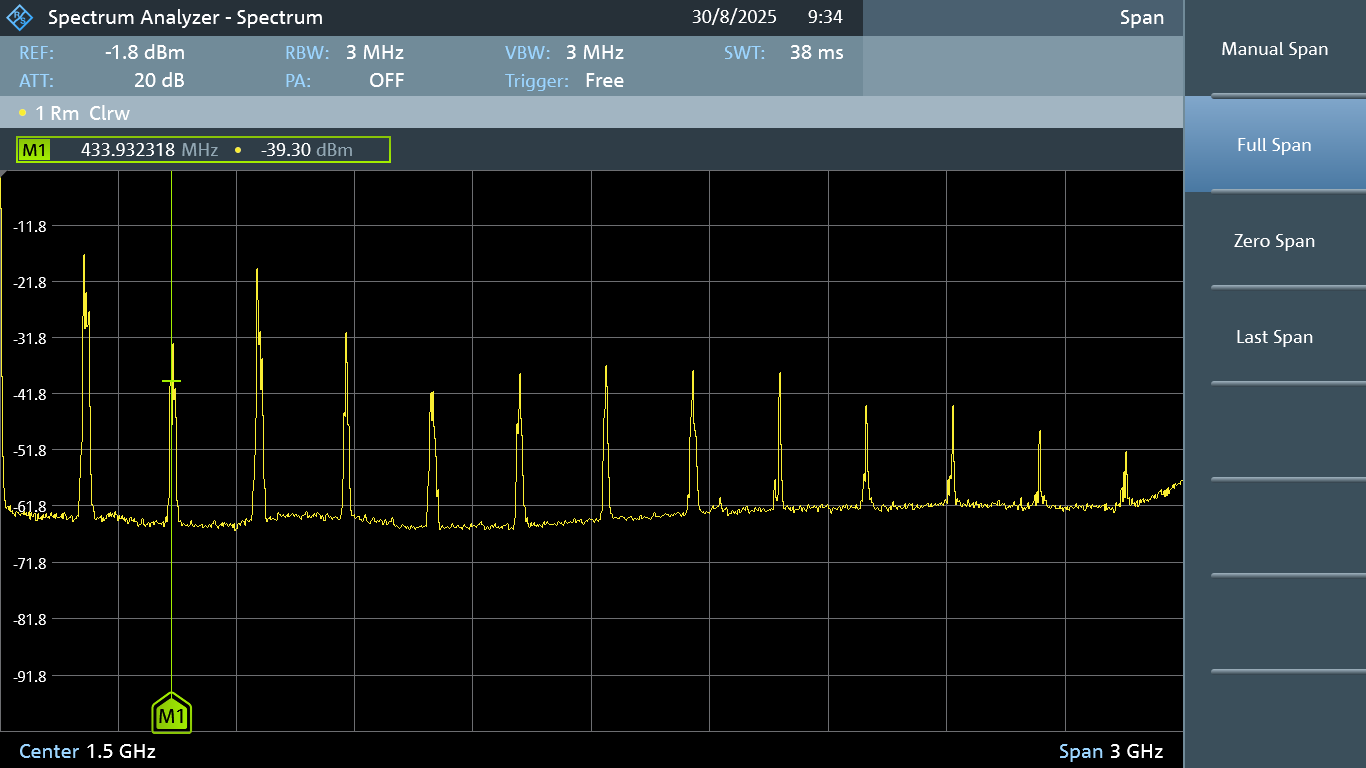

In [12]:
SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get("screenshot_path", "")
    shot_path = Path(shot_path_str) if shot_path_str else None
    if shot_path and shot_path.exists():
        print("Replay-Screenshot geladen:", shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print("REPLAY=True: Kein gültiger screenshot_path in Replay-Datei.")
        if shot_path_str:
            print("Gespeicherter Pfad (nicht gefunden):", shot_path_str)
else:
    err = screenshot_save(
        FPC_IP,
        FPC_PORT,
        SCREENSHOT_FILENAME,
        screenshot_timeout=SCREENSHOT_TIMEOUT,
    )
    if err:
        print("Screenshot (HCOP) Fehler:", err)
    else:
        png_bytes = screenshot_read(
            FPC_IP,
            FPC_PORT,
            SCREENSHOT_FILENAME,
            screenshot_timeout=SCREENSHOT_TIMEOUT,
        )
        if png_bytes:
            path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            path.write_bytes(png_bytes)
            print("Gespeichert:", path.resolve())
            display(Image(data=png_bytes))
            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay["screenshot_path"] = str(path)
                save_replay_json(REPLAY_FILE, replay)
                print("Replay aktualisiert mit screenshot_path:", REPLAY_FILE)
            except Exception as ex:
                print("screenshot_path konnte nicht gespeichert werden:", ex)
        else:
            print("Screenshot auf Gerät gespeichert; Lesen nicht möglich.")
